In [1]:
from typing_extensions import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver

from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.prebuilt import ToolNode

llm = ChatOllama(model="qwen3:1.7b")

c:\Users\wengshang.hoo\AppData\Local\miniconda3\envs\ai_sl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class AgentState(TypedDict):
    messages: Annotated[list,add_messages]

def call_agent(state: AgentState):
    system_message = SystemMessage("""You are a friendly assistant with memory. 
                                   
                                   You must first try to answer user query from your previous answers before making answer. Do not make answers by yourself if you are not sure.""")

    messages = [system_message] + state['messages']

    response = llm.invoke(messages)

    return {'messages':[response]}

In [3]:
import sqlite3
import os

os.makedirs('db',exist_ok=True)
db_path = "db/checkpoints.db"

conn = sqlite3.connect(db_path,check_same_thread=False)
checkpointer = SqliteSaver(conn)

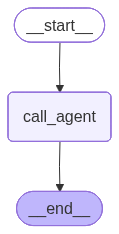

In [4]:
builder = StateGraph(AgentState)

builder.add_node("call_agent",call_agent)
builder.add_edge(START,"call_agent")
builder.add_edge("call_agent",END)

graph = builder.compile(checkpointer=checkpointer)
graph

In [7]:
config = {"configurable": {"thread_id": "1"}}
r1 = graph.invoke({'messages':"99*2 equal?"},config)
r1

{'messages': [HumanMessage(content='99*2 equal?', additional_kwargs={}, response_metadata={}, id='bb5a73ce-cc86-4a0e-b29c-2259ca631312'),
  AIMessage(content='99 multiplied by 2 equals **198**.  \n\n**Explanation:**  \n99 × 2 = (100 - 1) × 2 = 200 - 2 = **198**.', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T00:58:42.7668765Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14259454800, 'load_duration': 2901892100, 'prompt_eval_count': 59, 'prompt_eval_duration': 1367718400, 'eval_count': 217, 'eval_duration': 9475186000, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac0d-c112-70d3-a7e8-2f501af3c22e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 217, 'total_tokens': 276})]}

In [10]:
r2 = graph.invoke({'messages':"what is my last question"},config=config)
r2

{'messages': [HumanMessage(content='99*2 equal?', additional_kwargs={}, response_metadata={}, id='bb5a73ce-cc86-4a0e-b29c-2259ca631312'),
  AIMessage(content='99 multiplied by 2 equals **198**.  \n\n**Explanation:**  \n99 × 2 = (100 - 1) × 2 = 200 - 2 = **198**.', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T00:58:42.7668765Z', 'done': True, 'done_reason': 'stop', 'total_duration': 14259454800, 'load_duration': 2901892100, 'prompt_eval_count': 59, 'prompt_eval_duration': 1367718400, 'eval_count': 217, 'eval_duration': 9475186000, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac0d-c112-70d3-a7e8-2f501af3c22e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 59, 'output_tokens': 217, 'total_tokens': 276}),
  HumanMessage(content='what is my last question', additional_kwargs={}, response_metadata={}, id='c87443fb-dfbb-4ff2-bb4b-c72f92a1edc8'),
  AIMessage(content='Your last qu

In [13]:
# When thread id is change, ai will forgot what you ask
config2 = {"configurable": {"thread_id": "2"}}
r3 = graph.invoke({'messages':'what my last question?'},config=config2)
r3

{'messages': [HumanMessage(content='what my last question?', additional_kwargs={}, response_metadata={}, id='627af0e0-a066-4451-85aa-e84ecef7f306'),
  AIMessage(content="I don't have access to your previous questions or conversation history. If you're asking about your own last question, please rephrase or provide more context so I can assist you better. Let me know how I can help!", additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-03-02T01:05:52.8018748Z', 'done': True, 'done_reason': 'stop', 'total_duration': 12905153000, 'load_duration': 2050522600, 'prompt_eval_count': 58, 'prompt_eval_duration': 1332716100, 'eval_count': 187, 'eval_duration': 8881039200, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019cac14-5637-7a80-af62-d58fb1218a23-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 58, 'output_tokens': 187, 'total_tokens': 245})]}